# ДЗ-18 · Извлечение сущностей и событий из контрактов (NER + Information Extraction)

Извлекаем структурированную информацию из коммерческих контрактов **CUAD** с помощью локально развёрнутой инструктивной LLM в режиме zero/few-shot. Схема из 7 типов сущностей: `PERSON, ORG, MONEY, DATE, CONTRACT_TYPE, OBLIGATION, JURISDICTION`.

**Этапы (по заданию):**
1. Локальное развёртывание моделей (здесь — две маленькие модели Qwen2.5 на CPU; сравнение 7B quantized vs full — в `colab_7b.ipynb`).
2. Подготовка данных: подвыборка CUAD + промпты для извлечения.
3. Оптимизация: batch processing, измерение throughput.
4. Анализ: скорость (tokens/sec), качество (precision/recall/F1), ресурсы (RAM).

> ⚙️ **Где запускать.** Логика (парсинг, загрузка CUAD, метрики) работает везде. Сам inference требует рабочего `transformers`/`tokenizers`. На авторской Windows-машине связка `transformers 5.x / tokenizers 0.22` падает с access-violation, поэтому **inference-ячейки надёжнее всего запускать в Google Colab** (CPU или, лучше, T4 GPU). Загрузи туда `*.py` рядом с ноутбуком.

In [7]:
# В Colab раскомментируй установку зависимостей:
# !pip -q install transformers datasets accelerate psutil pandas matplotlib gradio

# Чтобы ноутбук видел наши модули (ie_extractor.py, data_prep.py, evaluate.py, benchmark.py),
# держи их в той же папке. В Colab можно загрузить через files.upload() или git clone.
import sys, os
print('python', sys.version.split()[0])

python 3.13.13


## Этап 2 — Подготовка данных (CUAD)

`data_prep.get_subset()` грузит SQuAD-формат CUAD (parquet-ветка хаба), группирует строки по контракту и из человеческой разметки строит **gold** по тем типам, что есть в CUAD: `CONTRACT_TYPE` (Document Name), `ORG` (Parties), `DATE` (Agreement/Effective/Expiration Date), `JURISDICTION` (Governing Law). По `PERSON/MONEY/OBLIGATION` gold в CUAD нет — их модель извлекает для demo, но в метриках они не штрафуются.

In [8]:
from data_prep import get_subset, gold_coverage, GOLD_ENTITY_TYPES

# 100–200 для demo; 500–1K для полноценного прогона (на CPU — долго).
samples = get_subset(n_docs=100, max_chars=2500)
print('контрактов:', len(samples))
print('типы с gold:', GOLD_ENTITY_TYPES)
print('покрытие gold (сумма спанов):', gold_coverage(samples))

[data_prep] CUAD загружен: 100 контрактов.
контрактов: 100
типы с gold: ['CONTRACT_TYPE', 'DATE', 'JURISDICTION', 'ORG']
покрытие gold (сумма спанов): {'PERSON': 0, 'ORG': 425, 'MONEY': 0, 'DATE': 106, 'CONTRACT_TYPE': 96, 'OBLIGATION': 0, 'JURISDICTION': 1}


In [9]:
ex = samples[0]
print('TITLE:', ex.title)
print('TEXT[:400]:\n', ex.text[:400])
print('\nGOLD:', {k: v for k, v in ex.gold.items() if v})

TITLE: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
TEXT[:400]:
 EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

                                    RECITALS

         A. The  Company's  Business.  The Company is  present

GOLD: {'ORG': ['Distributor', 'Electric City of Illinois LLC', 'Company', 'Electric City Corp.'], 'DATE': ['7th day of September, 1999.'], 'CONTRACT_TYPE': ['DISTRIBUTOR AGREEMENT']}


## Этап 1 + 3 — Развёртывание модели и batch-извлечение

Оборачиваем инструктивную модель в `Extractor`. Промпт (`build_messages`) фиксирует строгий JSON-формат и даёт one-shot пример — это стабилизирует маленькие модели. `parse_entities` устойчиво вытаскивает JSON даже из «болтливого» ответа.

> ⚡ **Про скорость.** На этой машине установлен CPU-only `torch` (нет CUDA-сборки), поэтому локальный инференс Qwen2.5-1.5B в fp32 на 20 документах занимает 14+ минут. Ниже используем `make_extractor(provider='openrouter')` — облачную модель через OpenRouter (ключ уже в `.env`), это на порядок быстрее и не требует переустановки torch. Сравнение размеров локальных моделей (0.5B vs 1.5B, batch_size) — в следующем разделе, там CPU оставлен намеренно, т.к. это часть задания.

In [10]:
from ie_extractor import Extractor, ENTITY_TYPES, build_messages

# посмотрим на промпт, который уйдёт в модель
for m in build_messages('Sample contract text ...'):
    print(f"[{m['role']}]\n{m['content'][:300]}\n")

[system]
You are a precise information-extraction engine for legal contracts. Extract entities and return ONLY a single JSON object, no prose, no markdown.
The JSON MUST have exactly these keys: "PERSON", "ORG", "MONEY", "DATE", "CONTRACT_TYPE", "OBLIGATION", "JURISDICTION".
Each value is a JSON array of str

[user]
TEXT:
This Services Agreement is entered into as of March 3, 2020 by and between Acme Corp. and John Smith. The Client shall pay $50,000. This Agreement shall be governed by the laws of the State of Delaware.

[assistant]
{"PERSON": ["John Smith"], "ORG": ["Acme Corp."], "MONEY": ["$50,000"], "DATE": ["March 3, 2020"], "CONTRACT_TYPE": ["Services Agreement"], "OBLIGATION": ["The Client shall pay $50,000"], "JURISDICTION": ["State of Delaware"]}

[user]
TEXT:
Sample contract text ...



In [11]:
# Локальный CPU-инференс на этой машине упирается в отсутствие CUDA-сборки torch
# (~14 минут даже на demo-выборке) — используем OpenRouter (ключ и модель в .env).
from ie_extractor import make_extractor

ext = make_extractor(provider='openrouter', max_new_tokens=384).load()

# Одиночное извлечение + статистика скорости
pred, stats = ext.extract_with_stats(samples[0].text)
print('STATS:', stats)
print('PRED :', {k: v for k, v in pred.items() if v})

STATS: {'gen_tokens': 126, 'seconds': 8.199979200027883, 'tokens_per_sec': 15.365892635382728}
PRED : {'ORG': ['Electric City Corp.', 'Electric City of Illinois LLC'], 'DATE': ['September 7, 1999'], 'CONTRACT_TYPE': ['DISTRIBUTOR AGREEMENT'], 'OBLIGATION': ['The Distributor has represented that it has or will have the facilities, personnel, and financial capability to promote the sale and use of Products', 'The Company has represented that it has the facilities, personnel and financial capability to have the Products produced and supplied as needed pursuant to the terms hereof'], 'JURISDICTION': ['State of Illinois']}


In [12]:
# Через API нет настоящего батчинга (ApiExtractor шлёт запросы последовательно,
# batch_size здесь только для совместимости интерфейса с локальным Extractor).
subset = samples[:20]                      # для demo берём 20
preds, bstats = ext.extract_batch([s.text for s in subset], batch_size=4)
print('batch stats:', bstats)

batch stats: {'n_docs': 20, 'batch_size': 4, 'seconds': 122.57256979995873, 'gen_tokens': 3113, 'tokens_per_sec': 25.397199431165458, 'docs_per_sec': 0.16316864395223551}


## Этап 4 — Анализ качества (precision / recall / F1)

Сравниваем предсказания с gold нечётко (нормализация + перекрытие токенов), считаем per-type и micro метрики только по типам, где есть gold.

In [13]:
from evaluate import evaluate, format_report

metrics = evaluate(preds, [s.gold for s in subset])
print(format_report(metrics))

ENTITY               P       R      F1    TP    FP    FN
--------------------------------------------------------
ORG              0.804   0.459   0.584    45    11    53
DATE             0.613   0.760   0.679    19    12     6
CONTRACT_TYPE    0.950   1.000   0.974    19     1     0
--------------------------------------------------------
MICRO            0.776   0.585   0.667    83    24    59


## Сравнение моделей и batch_size

`benchmark.benchmark_model` грузит модель один раз и гоняет на разных batch_size, возвращая скорость, качество и RAM. Сравним 0.5B и 1.5B.

In [14]:
from benchmark import benchmark_model
import pandas as pd

# Сокращённая выборка и max_new_tokens — это чисто CPU-бенчмарк локальных моделей
# (сравнение размера/batch_size, для этого API не подходит), поэтому держим его лёгким.
bench_samples = samples[:6]
results = []
for m in ['Qwen/Qwen2.5-0.5B-Instruct', 'Qwen/Qwen2.5-1.5B-Instruct']:
    results += benchmark_model(m, bench_samples, device='cpu', dtype='float32',
                               batch_sizes=[1, 4], max_new_tokens=192)

df = pd.DataFrame([{
    'model': r.model.split('/')[-1], 'batch': r.batch_size,
    'tok/s': r.tokens_per_sec, 'doc/s': r.docs_per_sec,
    'RAM_MB': r.ram_mb_peak, 'micro_F1': r.metrics.get('micro', {}).get('f1'),
} for r in results])
df


>>> Загрузка модели Qwen/Qwen2.5-0.5B-Instruct (dtype=float32, device=cpu) ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

    загружено за 6.0s; RAM=9377MB
    прогон batch_size=1 на 6 документах ...
    Qwen2.5-0.5B-Instruct      dtype=float32  bs=1 |    5.0 tok/s |  0.04 doc/s | RAM~  9458MB | F1=0.4762
    прогон batch_size=4 на 6 документах ...
    Qwen2.5-0.5B-Instruct      dtype=float32  bs=4 |    4.8 tok/s |  0.04 doc/s | RAM~  6057MB | F1=0.4762

>>> Загрузка модели Qwen/Qwen2.5-1.5B-Instruct (dtype=float32, device=cpu) ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

    загружено за 6.6s; RAM=9817MB
    прогон batch_size=1 на 6 документах ...
    Qwen2.5-1.5B-Instruct      dtype=float32  bs=1 |    1.9 tok/s |  0.02 doc/s | RAM~  7077MB | F1=0.7463
    прогон batch_size=4 на 6 документах ...
    Qwen2.5-1.5B-Instruct      dtype=float32  bs=4 |    2.1 tok/s |  0.02 doc/s | RAM~  7787MB | F1=0.7463


,model,batch,tok/s,doc/s,RAM_MB,micro_F1
0,Qwen2.5-0.5B-Instruct,1,4.95,0.043,9457.7,0.4762
1,Qwen2.5-0.5B-Instruct,4,4.84,0.042,6056.8,0.4762
2,Qwen2.5-1.5B-Instruct,1,1.92,0.016,7077.2,0.7463
3,Qwen2.5-1.5B-Instruct,4,2.13,0.018,7786.9,0.7463


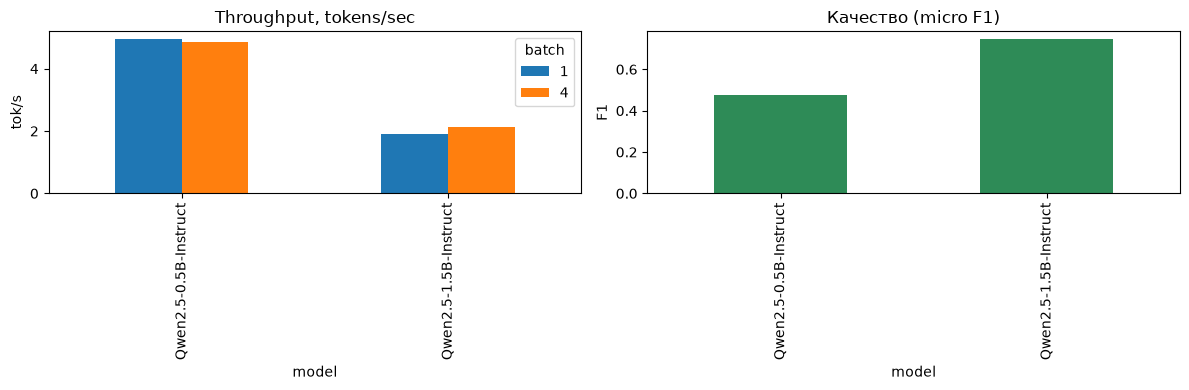

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
piv_speed = df.pivot(index='model', columns='batch', values='tok/s')
piv_speed.plot(kind='bar', ax=ax[0], title='Throughput, tokens/sec'); ax[0].set_ylabel('tok/s')
df.groupby('model')['micro_F1'].max().plot(kind='bar', ax=ax[1], color='seagreen',
    title='Качество (micro F1)'); ax[1].set_ylabel('F1')
plt.tight_layout(); plt.show()

### Потребление ресурсов
`RAM_MB` в таблице — пиковая RSS процесса (psutil). На GPU `benchmark` дополнительно пишет `vram_mb_peak`. Ожидаемо: 1.5B заметно тяжелее 0.5B по RAM и медленнее по tokens/sec, но обычно точнее. Батчинг (batch>1) повышает docs/sec на CPU за счёт параллельной генерации.

## Demo-приложение

Интерактивная демонстрация — `app.py` (Gradio): вставляешь текст контракта, получаешь подсвеченные сущности + JSON.

```bash
python app.py                 # http://127.0.0.1:7860
IE_MODEL=Qwen/Qwen2.5-0.5B-Instruct python app.py   # быстрее
```

В Colab можно запустить с `demo.launch(share=True)`.

In [16]:
# Быстрый inline-предпросмотр того, что показывает demo:
import app
txt = samples[0].text
ents = ext.extract(txt)
print('Сущности:', {k: v for k, v in ents.items() if v})
print('Сегменты подсветки:', app._to_highlighted(txt, ents)[:6])

Сущности: {'ORG': ['Electric City Corp.', 'Electric City of Illinois LLC'], 'DATE': ['September 7, 1999'], 'CONTRACT_TYPE': ['DISTRIBUTOR AGREEMENT'], 'OBLIGATION': ['The Distributor has represented that it has or will have the facilities, personnel, and financial capability to promote the sale and use of Products', 'The Company has represented that it has the facilities, personnel and financial capability to have the Products produced and supplied as needed pursuant to the terms hereof'], 'JURISDICTION': ['State of Illinois']}
Сегменты подсветки: [('EXHIBIT 10.6\n\n                              ', None), ('DISTRIBUTOR AGREEMENT', 'CONTRACT_TYPE'), ('\n\n         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between ', None), ('Electric City Corp.', 'ORG'), (',  a Delaware  corporation  ("Company")  and ', None), ('Electric City of Illinois LLC', 'ORG')]


## Выводы

* **LLM-as-extractor** позволяет извлекать 7 типов сущностей из юр-текстов без обучения отдельной NER-модели — достаточно промпта со строгой JSON-схемой и устойчивого парсера.
* **Gold из CUAD**: человеческую разметку 4 категорий удалось переиспользовать как gold, что даёт честный precision/recall без ручной разметки.
* **Размер vs скорость/качество**: 0.5B быстрее и легче по RAM, 1.5B точнее; батчинг повышает throughput на CPU.
* **7B и квантование** (4-bit vs full precision, VRAM, tokens/sec) — в `colab_7b.ipynb`.